# Unknown particle count from the rank-one KLT score distribution

This experiment asks whether the aggregated rank-one KLT detector can stop
without receiving the true particle count.

The detector is fitted **once** with the same best one-pass settings used in
the 51-particle control:

- untouched \(128^3\) raw ROI;
- \(D=33\), PSD patch \(25^3\);
- ACF `max_d=7` (the package default for a 25-voxel PSD patch);
- Fredholm radius \(0.4D=13.2\);
- template side 29 and NMS radius \(0.5D=16.5\).

The known count of 51 is used only to reproduce the previous control and to
calibrate/evaluate thresholds in this simulation. The score tensor is then
reused to extract a much longer NMS-ranked candidate list. No spectral fit or
score tensor is recomputed.

The notebook compares:

1. the normalized score distribution of the full score tensor;
2. scores of NMS peaks that do and do not match molecular GT;
3. precision, recall, and F1 over every possible score cutoff;
4. count-free cutoffs from a score-curve knee, Otsu thresholding, and a
   two-component Gaussian mixture.

The final threshold is empirical and dataset-specific. It is a feasibility
diagnostic, not yet a universally calibrated stopping rule.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jax
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from skimage.filters import threshold_otsu

from kltpicker_3d.tomogram import KLTParticleDetector3D
from kltpicker_3d.utils import ranked_local_maxima_nms_3d

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=5, suppress=True)

print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())

JAX: 0.10.2
JAX devices: [CpuDevice(id=0)]


## 1. Configuration and ROI

In [2]:
DATA_DIR = Path("data/tomotwin_2df7")
TOMOGRAM_PATH = DATA_DIR / "tiltseries_rec.mrc"
POSITIONS_PATH = DATA_DIR / "particle_positions.txt"

CLASS_DIAMETERS = {
    "1avo": 18,
    "1e9r": 21,
    "1fpy": 18,
    "1fzg": 28,
    "1jz8": 20,
    "1oao": 20,
    "2df7": 33,
}
CLASS_NAMES = list(CLASS_DIAMETERS)

ROI_START_ZYX = np.array([24, 16, 304], dtype=int)
ROI_SIZE = 128
KNOWN_TOTAL = 51

PARTICLE_DIAMETER = 33
PSD_PATCH_SIZE = 25
FREDHOLM_RADIUS = 13.2
TEMPLATE_SIDE = 29
NMS_RADIUS = 16.5
LEGENDRE_ORDER = 40
MAX_ANGULAR_ORDER = 4
EXTENDED_CANDIDATE_LIMIT = 500

roi_stop = ROI_START_ZYX + ROI_SIZE
with mrcfile.open(TOMOGRAM_PATH, permissive=True) as mrc:
    full_shape = np.asarray(mrc.data.shape)
    roi_slices = tuple(
        slice(int(start), int(stop))
        for start, stop in zip(ROI_START_ZYX, roi_stop)
    )
    raw_roi = np.asarray(mrc.data[roi_slices], dtype=np.float32).copy()

columns = ["class", "x", "y", "z", "rot1", "rot2", "rot3"]
positions = pd.read_csv(POSITIONS_PATH, header=None, names=columns)
positions["class"] = positions["class"].astype(str).str.lower()

gt_by_class = {}
for label in CLASS_NAMES:
    xyz = positions.loc[
        positions["class"] == label, ["x", "y", "z"]
    ].to_numpy(float)
    zyx = xyz[:, ::-1]
    inside = np.all(
        (zyx >= ROI_START_ZYX) & (zyx < roi_stop),
        axis=1,
    )
    gt_by_class[label] = zyx[inside] - ROI_START_ZYX

all_gt = np.concatenate([gt_by_class[label] for label in CLASS_NAMES])
all_gt_labels = np.concatenate([
    np.repeat(label, len(gt_by_class[label]))
    for label in CLASS_NAMES
])
all_gt_tolerances = np.array([
    0.5 * CLASS_DIAMETERS[str(label)]
    for label in all_gt_labels
])

count_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "diameter D": [CLASS_DIAMETERS[label] for label in CLASS_NAMES],
    "GT in ROI": [len(gt_by_class[label]) for label in CLASS_NAMES],
})

assert raw_roi.shape == (ROI_SIZE,) * 3
assert len(all_gt) == KNOWN_TOTAL

display(pd.Series({
    "ROI shape": raw_roi.shape,
    "known molecular GT count": len(all_gt),
    "particle diameter": PARTICLE_DIAMETER,
    "PSD patch": PSD_PATCH_SIZE,
    "ACF max_d": int(np.floor(0.3 * PSD_PATCH_SIZE)),
    "Fredholm radius": FREDHOLM_RADIUS,
    "template side": TEMPLATE_SIDE,
    "NMS radius": NMS_RADIUS,
}).to_frame("value"))
display(count_table)

,value
ROI shape,"(128, 128, 128)"
known molecular GT count,51
particle diameter,33
PSD patch,25
ACF max_d,7
Fredholm radius,13.2
template side,29
NMS radius,16.5


,class,diameter D,GT in ROI
0,1avo,18,8
1,1e9r,21,5
2,1fpy,18,4
3,1fzg,28,9
4,1jz8,20,4
5,1oao,20,9
6,2df7,33,12


## 2. Reproduce the known-count detector once

In [3]:
detector = KLTParticleDetector3D(
    raw_roi,
    particle_diameter=PARTICLE_DIAMETER,
    mgscale=1.0,
    num_particles=KNOWN_TOTAL,
    legendre_order=LEGENDRE_ORDER,
    threshold=-np.inf,
    max_iter=500,
    max_order=MAX_ANGULAR_ORDER,
    psd_patch_size=PSD_PATCH_SIZE,
    fredholm_radius=FREDHOLM_RADIUS,
    template_side=TEMPLATE_SIDE,
    bandpass_low_fraction=0.05,
    bandpass_high_fraction=0.05,
    nms_radius=NMS_RADIUS,
)

start = time.perf_counter()
known_returned, known_picks = detector.process_tomogram()
elapsed = time.perf_counter() - start

print(
    f"Detector completed in {elapsed:.1f} s; "
    f"returned {known_returned} known-count peaks."
)
print("Score tensor shape:", detector.score_mat.shape)
print("Score maximum:", float(np.max(detector.score_mat)))
assert known_returned == KNOWN_TOTAL

Detector completed in 12.3 s; returned 51 known-count peaks.
Score tensor shape: (100, 100, 100)
Score maximum: 419040.78125


## 3. Reuse the score tensor for count-free candidate ranking

The score tensor is not fitted again. We extract up to 500 local maxima using
the same spherical NMS radius and preserve their descending score order.

For evaluation, candidates are greedily matched in score order to the nearest
still-unmatched GT center within that class's \(D_k/2\) tolerance. This makes
the label of every prefix consistent with a thresholded ranked list.

In [5]:
score_volume = np.asarray(detector.score_mat)
score_maximum = float(np.max(score_volume))
template_offset = TEMPLATE_SIDE // 2

candidate_indices, candidate_scores = ranked_local_maxima_nms_3d(
    score_volume,
    radius=NMS_RADIUS,
    max_picks=EXTENDED_CANDIDATE_LIMIT,
)
candidate_centers = candidate_indices.astype(float) + template_offset
normalized_scores = candidate_scores / (score_maximum + 1e-12)

# The global maximum is an extreme unmatched peak in this ROI. Keep the
# package's max-normalized score for parity, but also define a robust scale
# from positive NMS peaks after excluding that single peak when it is more
# than ten times the second-ranked score.
positive_scores = candidate_scores[candidate_scores > 0]
exclude_extreme_first = (
    len(positive_scores) > 1
    and positive_scores[0] / positive_scores[1] > 10
)
robust_pool = (
    positive_scores[1:]
    if exclude_extreme_first
    else positive_scores
)
robust_score_scale = float(np.quantile(robust_pool, 0.99))
robust_normalized_scores = candidate_scores / robust_score_scale

def greedy_ranked_matches(centers):
    distances = cdist(centers, all_gt)
    unmatched_gt = np.ones(len(all_gt), dtype=bool)
    matched_gt_index = np.full(len(centers), -1, dtype=int)
    match_distance = np.full(len(centers), np.nan)

    for candidate_index in range(len(centers)):
        valid = (
            unmatched_gt
            & (distances[candidate_index] <= all_gt_tolerances)
        )
        if not np.any(valid):
            continue
        valid_indices = np.flatnonzero(valid)
        nearest = valid_indices[
            np.argmin(distances[candidate_index, valid_indices])
        ]
        matched_gt_index[candidate_index] = nearest
        match_distance[candidate_index] = distances[candidate_index, nearest]
        unmatched_gt[nearest] = False

    labels = np.full(len(centers), "unmatched", dtype=object)
    accepted = matched_gt_index >= 0
    labels[accepted] = all_gt_labels[matched_gt_index[accepted]]
    return accepted, labels, match_distance


is_matched, candidate_labels, match_distances = greedy_ranked_matches(
    candidate_centers
)

candidates = pd.DataFrame({
    "rank": np.arange(1, len(candidate_scores) + 1),
    "raw_score": candidate_scores,
    "normalized_score": normalized_scores,
    "robust_normalized_score": robust_normalized_scores,
    "matched": is_matched,
    "posthoc_class": candidate_labels,
    "match_distance_vox": match_distances,
})

print(
    f"Extended NMS returned {len(candidates)} candidates; "
    f"{int(is_matched.sum())}/{len(all_gt)} GT centers are reachable "
    "somewhere in this ranked list."
)
print(
    f"Top/second score ratio={candidate_scores[0] / candidate_scores[1]:.1f}; "
    f"robust positive-peak scale={robust_score_scale:.3f}."
)
display(candidates.head(15))

Extended NMS returned 167 candidates; 39/51 GT centers are reachable somewhere in this ranked list.
Top/second score ratio=34.0; robust positive-peak scale=9577.740.


,rank,raw_score,normalized_score,robust_normalized_score,matched,posthoc_class,match_distance_vox
0,1,419040.781250,1.000000,43.751530,False,unmatched,NaN
1,2,12311.835938,0.029381,1.285464,True,2df7,4.193308
2,3,9839.872070,0.023482,1.027369,True,2df7,2.647638
3,4,9068.897461,0.021642,0.946872,True,2df7,3.185497
4,5,8968.335938,0.021402,0.936373,True,2df7,2.380314
5,6,8569.336914,0.020450,0.894714,True,2df7,3.499841
6,7,8525.217773,0.020345,0.890107,True,2df7,3.102109
7,8,8166.120117,0.019488,0.852614,True,2df7,6.371679
8,9,7821.026367,0.018664,0.816584,True,2df7,5.149335
9,10,7797.151367,0.018607,0.814091,True,2df7,5.182389


## 4. Full-volume and NMS-peak score distributions

In [13]:
finite_voxel_scores

array([-243.93365, -298.23267, -332.7193 , ...,  364.84998,  372.04614,
        388.8838 ], shape=(1000000,), dtype=float32)

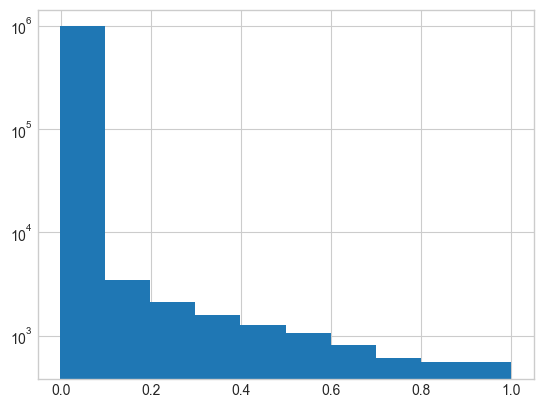

In [17]:
plt.hist(finite_voxel_scores/np.max(finite_voxel_scores))
plt.yscale('log')

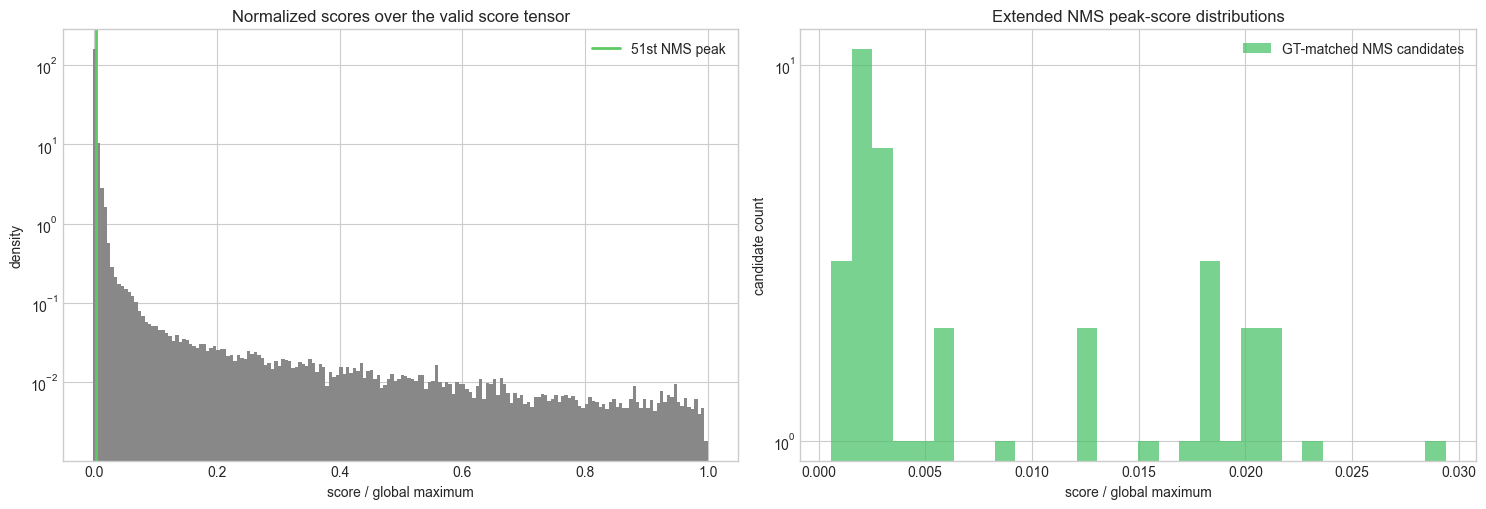

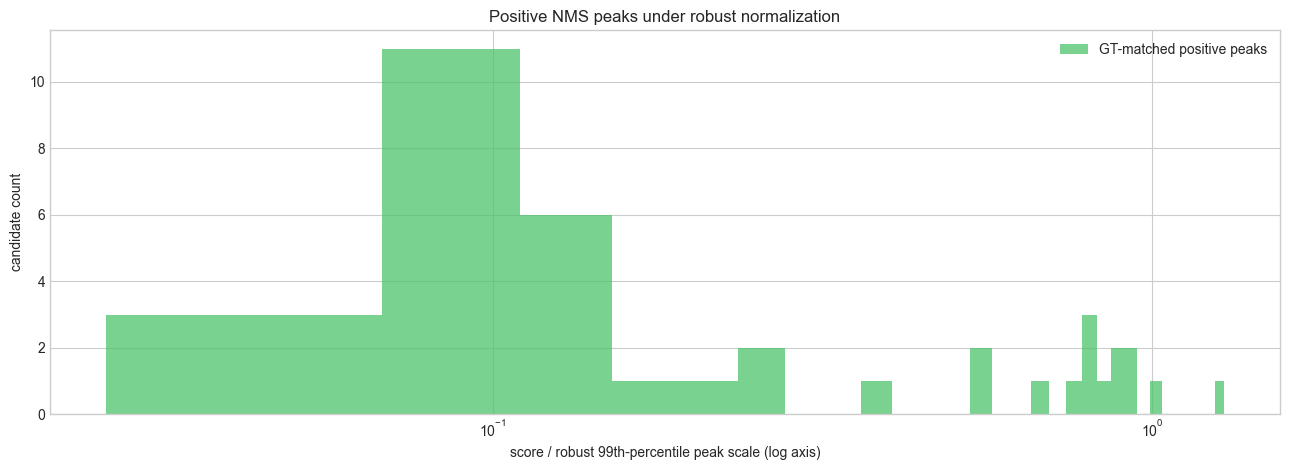

In [25]:
finite_voxel_scores = score_volume[np.isfinite(score_volume)].ravel()
finite_voxel_normalized = finite_voxel_scores / (score_maximum + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

lo, hi = np.quantile(finite_voxel_normalized, [0.001, 0.999])
axes[0].hist(
    finite_voxel_normalized,
    bins=180,
    density=True,
    color=plt.cm.Greys(0.55),
)
#axes[0].set_xlim(lo, hi)
axes[0].set(
    title="Normalized scores over the valid score tensor",
    xlabel=r"score / global maximum",
    ylabel="density",
)
axes[0].axvline(
    normalized_scores[KNOWN_TOTAL - 1],
    color=plt.cm.viridis(0.75),
    linewidth=2,
    label="51st NMS peak",
)
axes[0].legend()
axes[0].set_yscale('log')

# axes[1].hist(
#     normalized_scores[~is_matched],
#     bins=45,
#     alpha=0.65,
#     label="unmatched NMS candidates",
#     color=plt.cm.Greys(0.45),
# )
axes[1].hist(
    normalized_scores[is_matched],
    bins=30,
    alpha=0.75,
    label="GT-matched NMS candidates",
    color=plt.cm.viridis(0.72),
)
axes[1].set(
    title="Extended NMS peak-score distributions",
    xlabel=r"score / global maximum",
    ylabel="candidate count",
)
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4.8))
positive = candidate_scores > 0
# ax.hist(
#     robust_normalized_scores[positive & ~is_matched],
#     bins=45,
#     alpha=0.65,
#     label="unmatched positive peaks",
#     color=plt.cm.Greys(0.45),
# )
ax.hist(
    robust_normalized_scores[positive & is_matched],
    bins=30,
    alpha=0.75,
    label="GT-matched positive peaks",
    color=plt.cm.viridis(0.72),
)
ax.set_xscale("log")
ax.set(
    title="Positive NMS peaks under robust normalization",
    xlabel="score / robust 99th-percentile peak scale (log axis)",
    ylabel="candidate count",
)
ax.legend()
plt.tight_layout()
plt.show()

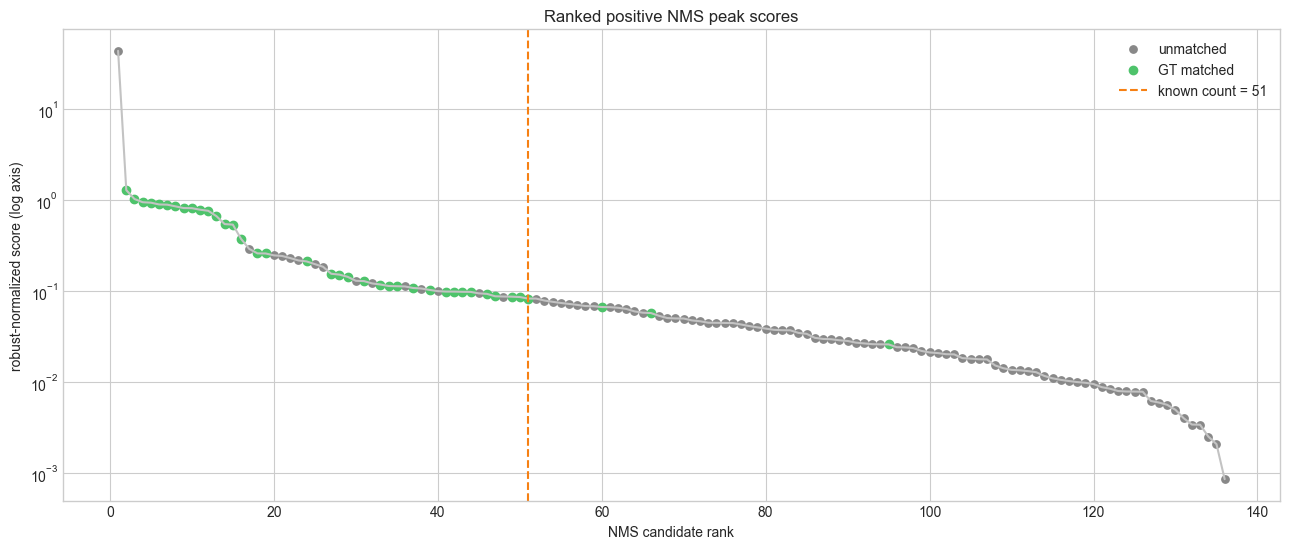

In [6]:
plot_limit = int(np.sum(candidate_scores > 0))
fig, ax = plt.subplots(figsize=(13, 5.6))

ax.plot(
    candidates["rank"][:plot_limit],
    candidates["robust_normalized_score"][:plot_limit],
    color=plt.cm.Greys(0.35),
    linewidth=1.5,
)
ax.scatter(
    candidates.loc[:plot_limit - 1, "rank"][~is_matched[:plot_limit]],
    candidates.loc[:plot_limit - 1, "robust_normalized_score"][~is_matched[:plot_limit]],
    s=28,
    color=plt.cm.Greys(0.55),
    label="unmatched",
)
ax.scatter(
    candidates.loc[:plot_limit - 1, "rank"][is_matched[:plot_limit]],
    candidates.loc[:plot_limit - 1, "robust_normalized_score"][is_matched[:plot_limit]],
    s=36,
    color=plt.cm.viridis(0.72),
    label="GT matched",
)
ax.axvline(KNOWN_TOTAL, color=plt.cm.inferno(0.72), linestyle="--", label="known count = 51")
ax.set_yscale("log")
ax.set(
    title="Ranked positive NMS peak scores",
    xlabel="NMS candidate rank",
    ylabel="robust-normalized score (log axis)",
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Oracle threshold curve

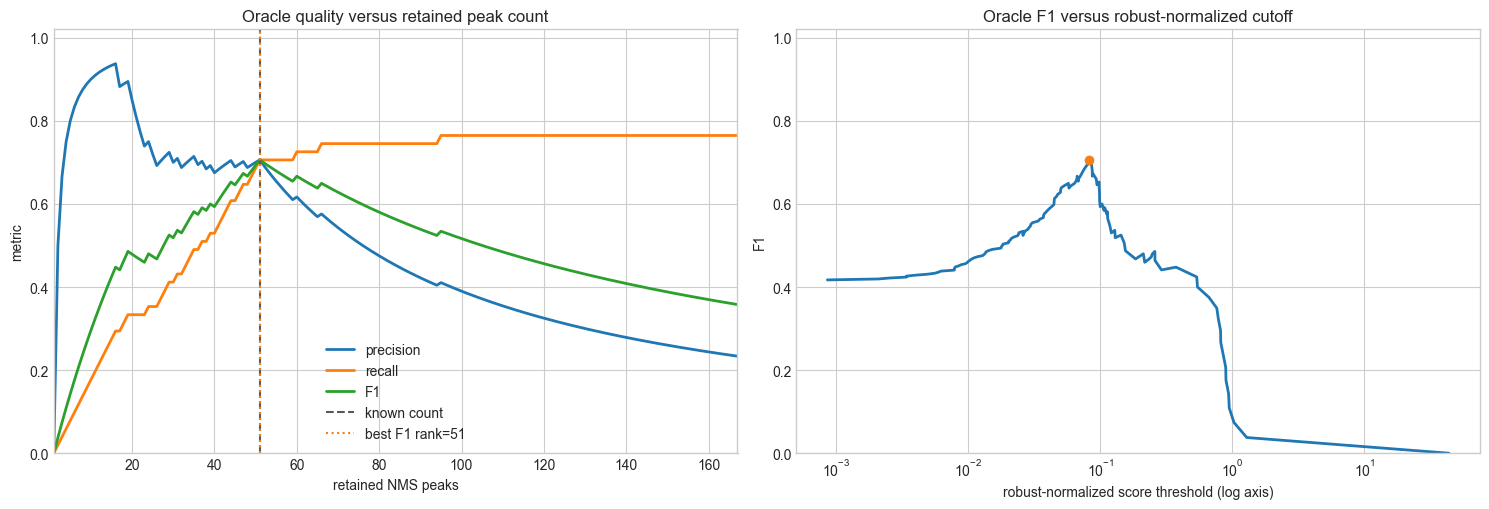

Known-count metrics: {'TP': 36, 'precision': 0.7058823529411765, 'recall': 0.7058823529411765, 'F1': 0.7058823529411765}
Oracle best F1=0.706 at 51 peaks and normalized threshold 0.00188781.


In [26]:
cumulative_tp = np.cumsum(is_matched).astype(int)
predicted_count = np.arange(1, len(candidates) + 1)
precision = cumulative_tp / predicted_count
recall = cumulative_tp / len(all_gt)
f1 = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(precision),
    where=(precision + recall) > 0,
)

best_f1_index = int(np.argmax(f1))
best_f1_rank = best_f1_index + 1
best_f1_threshold = float(normalized_scores[best_f1_index])

known_count_index = KNOWN_TOTAL - 1
known_count_metrics = {
    "TP": int(cumulative_tp[known_count_index]),
    "precision": float(precision[known_count_index]),
    "recall": float(recall[known_count_index]),
    "F1": float(f1[known_count_index]),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

axes[0].plot(predicted_count, precision, label="precision", linewidth=2)
axes[0].plot(predicted_count, recall, label="recall", linewidth=2)
axes[0].plot(predicted_count, f1, label="F1", linewidth=2)
axes[0].axvline(KNOWN_TOTAL, color="0.35", linestyle="--", label="known count")
axes[0].axvline(
    best_f1_rank,
    color=plt.cm.inferno(0.72),
    linestyle=":",
    label=f"best F1 rank={best_f1_rank}",
)
axes[0].set(
    title="Oracle quality versus retained peak count",
    xlabel="retained NMS peaks",
    ylabel="metric",
    xlim=(1, min(180, len(candidates))),
    ylim=(0, 1.02),
)
axes[0].legend()

positive_candidate_count = int(np.sum(candidate_scores > 0))
axes[1].plot(
    robust_normalized_scores[:positive_candidate_count],
    f1[:positive_candidate_count],
    linewidth=2,
)
axes[1].scatter(
    [candidate_scores[best_f1_index] / robust_score_scale],
    [f1[best_f1_index]],
    color=plt.cm.inferno(0.72),
    zorder=3,
)
axes[1].set_xscale("log")
axes[1].set(
    title="Oracle F1 versus robust-normalized cutoff",
    xlabel="robust-normalized score threshold (log axis)",
    ylabel="F1",
    ylim=(0, 1.02),
)
#axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

print("Known-count metrics:", known_count_metrics)
print(
    f"Oracle best F1={f1[best_f1_index]:.3f} at "
    f"{best_f1_rank} peaks and normalized threshold "
    f"{best_f1_threshold:.6g}."
)

## 6. Count-free score thresholds

In [8]:
def threshold_metrics(threshold):
    count = int(np.sum(normalized_scores >= threshold))
    if count == 0:
        return {
            "threshold": threshold,
            "predicted_count": 0,
            "TP": 0,
            "FP": 0,
            "precision": np.nan,
            "recall": 0.0,
            "F1": 0.0,
        }
    index = count - 1
    tp = int(cumulative_tp[index])
    return {
        "threshold": float(threshold),
        "predicted_count": count,
        "TP": tp,
        "FP": count - tp,
        "precision": float(precision[index]),
        "recall": float(recall[index]),
        "F1": float(f1[index]),
    }


# Oracle references, used only to understand the score distribution.
if KNOWN_TOTAL < len(normalized_scores):
    known_count_threshold = 0.5 * (
        normalized_scores[KNOWN_TOTAL - 1]
        + normalized_scores[KNOWN_TOTAL]
    )
else:
    known_count_threshold = normalized_scores[-1]

# Geometric knee: maximum distance above the endpoint chord of the descending
# score curve. The first two ranks are excluded to reduce single-outlier bias.
knee_pool = min(250, len(normalized_scores))
knee_scores = normalized_scores[:knee_pool]
x = np.linspace(0.0, 1.0, knee_pool)
y = (knee_scores - knee_scores[-1]) / (
    knee_scores[0] - knee_scores[-1] + 1e-12
)
endpoint_chord = 1.0 - x
knee_distance = y - endpoint_chord
knee_index = int(np.argmax(knee_distance[2:]) + 2)
knee_threshold = float(knee_scores[knee_index])

# Otsu on the original linear normalization illustrates sensitivity to the
# extreme first peak.
otsu_threshold = float(threshold_otsu(normalized_scores))

# A two-component Gaussian mixture provides a second unsupervised split.
gmm = GaussianMixture(n_components=2, n_init=20, random_state=7)
gmm.fit(normalized_scores[:, None])
high_component = int(np.argmax(gmm.means_.ravel()))
posterior_high = gmm.predict_proba(normalized_scores[:, None])[:, high_component]
high_mask = posterior_high >= 0.5
gmm_threshold = (
    float(np.min(normalized_scores[high_mask]))
    if np.any(high_mask)
    else float(np.inf)
)

# More robust alternatives operate on log positive scores. The GMM excludes
# the first peak only when it is an extreme outlier by the rule above.
log_otsu_raw_threshold = float(
    np.exp(threshold_otsu(np.log(positive_scores)))
)
log_otsu_threshold = log_otsu_raw_threshold / score_maximum

robust_log_scores = np.log(robust_pool)
robust_gmm = GaussianMixture(n_components=2, n_init=20, random_state=7)
robust_gmm.fit(robust_log_scores[:, None])
robust_high_component = int(np.argmax(robust_gmm.means_.ravel()))
robust_assignments = robust_gmm.predict(robust_log_scores[:, None])
robust_high_scores = robust_pool[
    robust_assignments == robust_high_component
]
robust_gmm_raw_threshold = float(np.min(robust_high_scores))
robust_gmm_threshold = robust_gmm_raw_threshold / score_maximum

thresholds = {
    "known-count midpoint (oracle)": known_count_threshold,
    "oracle best F1": best_f1_threshold,
    "score-curve knee": knee_threshold,
    "Otsu on NMS peaks": otsu_threshold,
    "2-component GMM": gmm_threshold,
    "log-Otsu on positive peaks": log_otsu_threshold,
    "robust log-GMM": robust_gmm_threshold,
}

threshold_table = pd.DataFrame([
    {"method": method, **threshold_metrics(value)}
    for method, value in thresholds.items()
]).sort_values("predicted_count")
threshold_table["raw_threshold"] = (
    threshold_table["threshold"] * score_maximum
)
threshold_table["robust_normalized_threshold"] = (
    threshold_table["raw_threshold"] / robust_score_scale
)

display(threshold_table.round(5))

,method,threshold,predicted_count,TP,FP,precision,recall,F1,raw_threshold,robust_normalized_threshold
4,2-component GMM,1.00000,1,0,1,0.00000,0.00000,0.00000,419040.78125,43.75153
3,Otsu on NMS peaks,0.02843,2,1,1,0.50000,0.01961,0.03774,11914.50174,1.24398
0,known-count midpoint (oracle),0.00189,51,36,15,0.70588,0.70588,0.70588,790.76066,0.08256
1,oracle best F1,0.00189,51,36,15,0.70588,0.70588,0.70588,791.06921,0.08259
6,robust log-GMM,0.00145,63,37,26,0.58730,0.72549,0.64912,608.43567,0.06353
5,log-Otsu on positive peaks,0.00121,67,38,29,0.56716,0.74510,0.64407,508.22034,0.05306
2,score-curve knee,-0.00089,167,39,128,0.23353,0.76471,0.35780,-373.01177,-0.03895


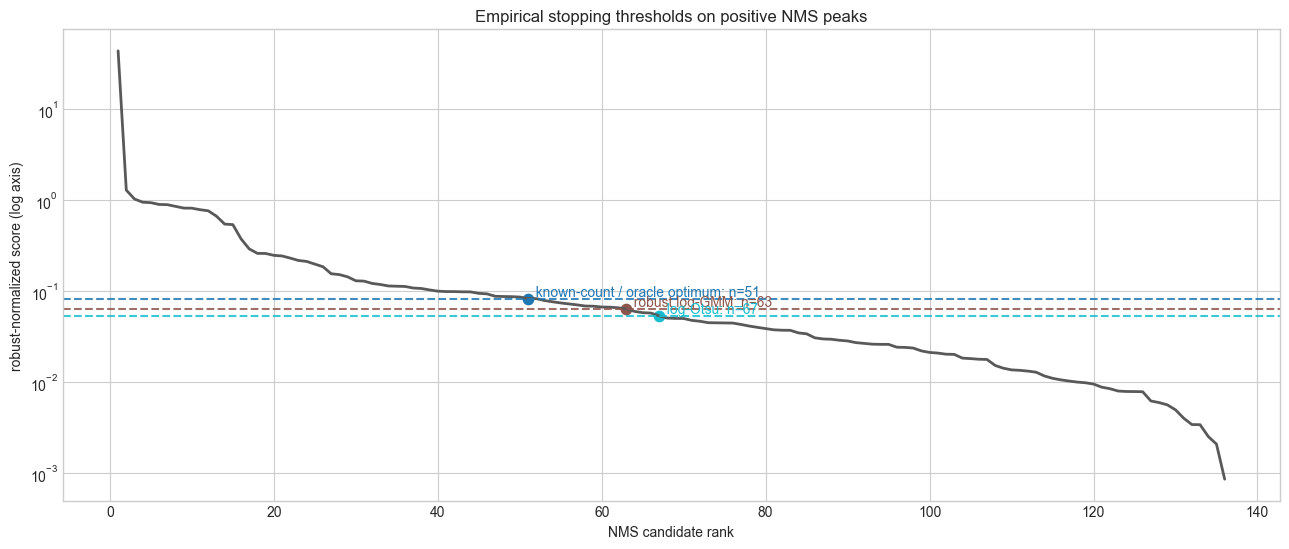

In [9]:
fig, ax = plt.subplots(figsize=(13, 5.6))
display_count = int(np.sum(candidate_scores > 0))
ax.plot(
    np.arange(1, display_count + 1),
    robust_normalized_scores[:display_count],
    color="0.35",
    linewidth=2,
)

plot_thresholds = {
    "known-count / oracle optimum": known_count_threshold,
    "robust log-GMM": robust_gmm_threshold,
    "log-Otsu": log_otsu_threshold,
}
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_thresholds)))
for color, (method, threshold) in zip(colors, plot_thresholds.items()):
    count = int(np.sum(normalized_scores >= threshold))
    robust_threshold = threshold * score_maximum / robust_score_scale
    if robust_threshold <= 0:
        continue
    ax.axhline(robust_threshold, color=color, linestyle="--", alpha=0.85)
    if 0 < count <= display_count:
        ax.scatter(count, robust_normalized_scores[count - 1], color=color, s=55)
        ax.text(
            count,
            robust_normalized_scores[count - 1],
            f"  {method}: n={count}",
            color=color,
            va="bottom",
        )

ax.set_yscale("log")
ax.set(
    title="Empirical stopping thresholds on positive NMS peaks",
    xlabel="NMS candidate rank",
    ylabel="robust-normalized score (log axis)",
)
plt.tight_layout()
plt.show()

## 7. Scores among the 51 previously retained particles

Normalized scores inside the known-count top-51 result


,count,min,median,mean,max
matched,,,,,
unmatched,15,0.001988,0.004223,0.070261,1.000000
GT matched,36,0.001888,0.004185,0.009410,0.029381


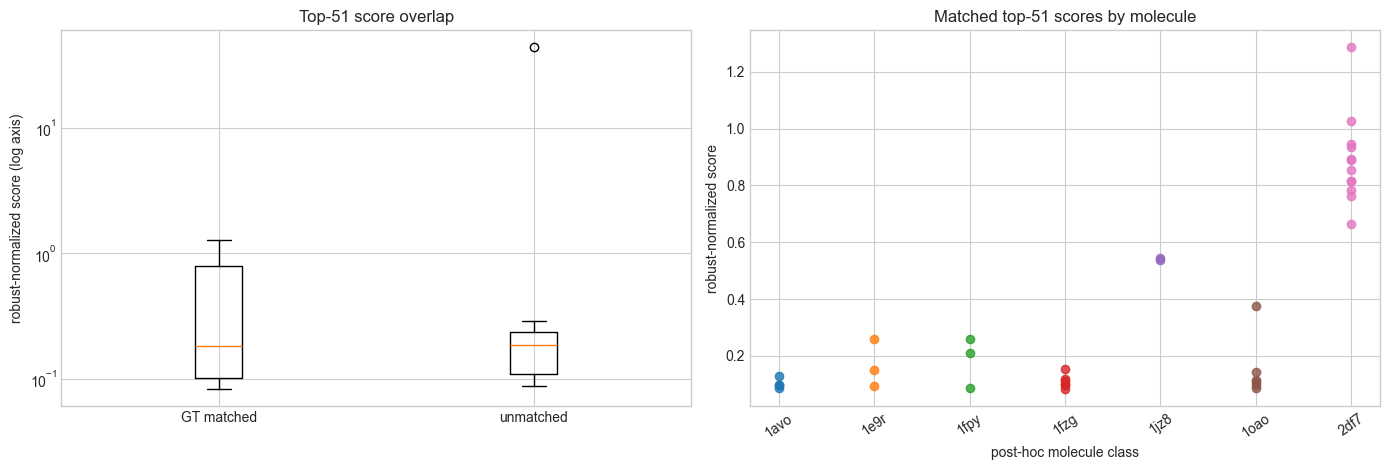

In [10]:
top_known = candidates.iloc[:KNOWN_TOTAL].copy()
top_known_summary = (
    top_known.groupby("matched")["normalized_score"]
    .agg(["count", "min", "median", "mean", "max"])
    .rename(index={False: "unmatched", True: "GT matched"})
)

print("Normalized scores inside the known-count top-51 result")
display(top_known_summary.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(
    [
        top_known.loc[top_known["matched"], "robust_normalized_score"],
        top_known.loc[~top_known["matched"], "robust_normalized_score"],
    ],
    tick_labels=["GT matched", "unmatched"],
    showfliers=True,
)
axes[0].set_yscale("log")
axes[0].set(
    title="Top-51 score overlap",
    ylabel="robust-normalized score (log axis)",
)

for label in CLASS_NAMES:
    values = top_known.loc[
        top_known["posthoc_class"] == label, "robust_normalized_score"
    ]
    if len(values):
        axes[1].scatter(
            np.repeat(label, len(values)),
            values,
            alpha=0.8,
            label=label,
        )
axes[1].set(
    title="Matched top-51 scores by molecule",
    xlabel="post-hoc molecule class",
    ylabel="robust-normalized score",
)
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 8. Empirical conclusion and saved outputs

In [11]:
COUNT_FREE_METHODS = [
    "score-curve knee",
    "Otsu on NMS peaks",
    "2-component GMM",
    "log-Otsu on positive peaks",
    "robust log-GMM",
]
count_free_results = (
    threshold_table[
        threshold_table["method"].isin(COUNT_FREE_METHODS)
    ]
    .sort_values(["F1", "precision", "recall"], ascending=False)
)
best_count_free = count_free_results.iloc[0]

print(
    "Best count-free rule in this simulation:\n"
    f"  {best_count_free['method']}\n"
    f"  raw threshold = {best_count_free['raw_threshold']:.6g}\n"
    f"  package max-normalized threshold = "
    f"{best_count_free['threshold']:.6g}\n"
    f"  robust-normalized threshold = "
    f"{best_count_free['robust_normalized_threshold']:.6g}\n"
    f"  predicted count = {int(best_count_free['predicted_count'])}\n"
    f"  TP/FP = {int(best_count_free['TP'])}/{int(best_count_free['FP'])}\n"
    f"  precision/recall/F1 = "
    f"{best_count_free['precision']:.3f}/"
    f"{best_count_free['recall']:.3f}/"
    f"{best_count_free['F1']:.3f}"
)

if (
    top_known.loc[top_known["matched"], "normalized_score"].min()
    <= top_known.loc[~top_known["matched"], "normalized_score"].max()
):
    print(
        "\nMatched and unmatched scores overlap inside the top-51 list. "
        "Therefore no single score threshold can reproduce the oracle labels "
        "perfectly on this ROI."
    )

print(
    "\nGuardrail: the method comparison is calibrated with GT from one "
    "simulation. A deployable threshold should be validated across other "
    "tomograms and should not use the known count or oracle-best-F1 cutoff."
)

candidates.to_csv("unknown_count_score_candidates.csv", index=False)
threshold_table.to_csv("unknown_count_score_thresholds.csv", index=False)
np.savez_compressed(
    "unknown_count_score_analysis.npz",
    candidate_centers=candidate_centers,
    candidate_scores=candidate_scores,
    normalized_scores=normalized_scores,
    robust_normalized_scores=robust_normalized_scores,
    robust_score_scale=robust_score_scale,
    is_matched=is_matched,
    candidate_labels=candidate_labels,
    score_shape=np.asarray(score_volume.shape),
)

print("\nSaved:")
print("  unknown_count_score_candidates.csv")
print("  unknown_count_score_thresholds.csv")
print("  unknown_count_score_analysis.npz")

Best count-free rule in this simulation:
  robust log-GMM
  raw threshold = 608.436
  package max-normalized threshold = 0.00145197
  robust-normalized threshold = 0.063526
  predicted count = 63
  TP/FP = 37/26
  precision/recall/F1 = 0.587/0.725/0.649

Matched and unmatched scores overlap inside the top-51 list. Therefore no single score threshold can reproduce the oracle labels perfectly on this ROI.

Guardrail: the method comparison is calibrated with GT from one simulation. A deployable threshold should be validated across other tomograms and should not use the known count or oracle-best-F1 cutoff.

Saved:
  unknown_count_score_candidates.csv
  unknown_count_score_thresholds.csv
  unknown_count_score_analysis.npz
